In [278]:
import roboticstoolbox as rtb
import numpy as np
from spatialmath import SE3

In [279]:
# Define Links
link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=-0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=-0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=-0.0, alpha=0.0)

# Create the Robot Object
ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="UR3e")

print(ur3e)

DHRobot: UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │      -0 │  90.0° │
│  q5 │ 0.08535 │      -0 │ -90.0° │
│  q6 │  0.0921 │      -0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



## Understanding the FK Output
The output you see above is a 4x4 Homogeneous Transformation Matrix.

   [ r11   r12   r13   tx ]
   [ r21   r22   r23   ty ]
   [ r31   r32   r33   tz ]
   [  0     0     0     1 ]

- Top-Left 3x3 (r values): Represents the Rotation (orientation) of the tool frame relative to the base.
- Right Column (tx, ty, tz): Represents the Translation (position X, Y, Z) of the tool frame relative to the base.

While matrices are great for math, they are hard for humans to read. We often convert this to XYZ (Position) and RPY (Roll-Pitch-Yaw / Orientation) for easier inspection.

In [280]:
tcp_pos = np.array([0.2, 0.2, 0.2])
tcp_rot = np.array([0, 0, 0])

T = SE3(tcp_pos) * SE3.RPY(tcp_rot)

sol = ur3e.ikine_LM(T)
print(sol.q)

[ 1.26714922 -2.37462438 -2.38496534  0.04720074 -1.57079633 -2.83794554]


In [281]:
T_check = ur3e.fkine(sol.q)
print("\nCheck Pose:\n", T_check.t)


Check Pose:
 [0.2        0.19999993 0.20000032]


In [346]:
from pathlib import Path
import time
from communication.typed_protocol_client import TypedRabbitMQClient
from communication.typed_protocol import StuckJointStatus, LoadTCPProgram, LoadProgram, Play
from communication.rabbitmq import Rabbitmq
import roboticstoolbox as rtb
from spatialmath import SE3
import numpy as np

def build_ur3e(stuck_joints=None, joint_angles=None) -> rtb.ERobot:
    DH = [
        (0.15185, 0.0,      np.pi / 2),
        (0.0,    -0.24355,  0.0),
        (0.0,    -0.2132,   0.0),
        (0.13105, 0.0,      np.pi / 2),
        (0.08535, 0.0,     -np.pi / 2),
        (0.0921,  0.0,      0.0),
    ]
    ets = rtb.ETS()
    for i, (d, a, alpha) in enumerate(DH):
        if stuck_joints and stuck_joints[i]:
            ets *= rtb.ET.Rz(joint_angles[i])
        else:
            ets *= rtb.ET.Rz()
        ets *= rtb.ET.tz(d) # Apply Z translation
        ets *= rtb.ET.tx(a) # Apply X translation
        ets *= rtb.ET.Rx(alpha)
    return rtb.ERobot(ets, name="UR3e")


class BreakableRobot:
    def __init__(self, rabbit_mq_client: TypedRabbitMQClient = None):
        self.stuck_joints = [False] * 6
        self.joint_angles = [0] * 6
        self.ur3e = self._init_ur3e()

        if rabbit_mq_client != None:
            self.rabbit_mq_client = rabbit_mq_client

    def _init_ur3e(self) -> rtb.ERobot:
        return build_ur3e(self.stuck_joints, self.joint_angles)

    def inv_kinematics(self, tcp_pos: np.ndarray, tcp_rot: np.ndarray, 
                   publish: bool = True, ignore_all_rotations=False) -> np.ndarray:
    
        T = SE3(tcp_pos) * SE3.RPY(tcp_rot)
        num_stuck = int(np.sum(self.stuck_joints))
        
        # --- MASK LOGIC ---
        if ignore_all_rotations:
            # Strict 3D position only. Great for debugging reachability!
            mask = [1, 1, 1, 0, 0, 0] 
        else:
            mask = [10, 10, 10, 1, 1, 1]
            for i in range(num_stuck):
                mask[5 - i] = 0
                    
        # Define max retries for IK attempts with random initializations
        max_retries = 10
        success = False
        
        for attempt in range(max_retries):
            # Generate a random initial guess (q0) within joint limits roughly -pi to pi
            if attempt == 0:
                q0 = self.joint_angles # Start searching with the current position as start value
            else: # Search elsewhere
                q0 = np.random.uniform(-np.pi, np.pi, self.ur3e.n)
            
            sol = self.ur3e.ikine_GN(T, mask=mask, q0=q0)
            
            if sol.success:
                success = True
                break # We found a solution, stop searching
                
        if not success:
            print(f"\nWarning: IK totally failed after {max_retries} attempts.")
            print(f"Reason: {sol.reason}")
            print("This pose is likely physically unreachable with the current stuck joints.")
        
        # Re-introdcue the stuck joints to the commanded joint angles
        full_q = np.zeros(len(self.stuck_joints))
        active_q_idx = 0
        
        for i, is_stuck in enumerate(self.stuck_joints):
            if is_stuck:
                full_q[i] = self.joint_angles[i]
            else:
                full_q[i] = sol.q[active_q_idx]
                active_q_idx += 1

        if publish:
            self.rabbit_mq_client.publish(
                LoadProgram(joint_positions=full_q.tolist(), max_velocity=60, acceleration=80)
            )
            self.rabbit_mq_client.publish(
                Play()
            )

        return full_q

    def update_state(self, body: StuckJointStatus):
        self.stuck_joints = body.stuck_joints 
        self.joint_angles = body.joint_positions 
        self.ur3e = self._init_ur3e()



Check Pose:
 [0.09999988 0.10000051 0.29999974]
Q:  [ 2.74156208 -0.21385335 -1.84245442 -2.65608112  1.5707965   1.17076575]
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.51850000e-01]
 [ 2.43550000e-01  1.82633248e-33  1.51850000e-01]
 [ 4.56750000e-01  3.42507640e-33  1.51850000e-01]
 [ 4.56750000e-01 -1.31050000e-01  1.51850000e-01]
 [ 5.42100000e-01 -1.31050000e-01  1.51850000e-01]
 [ 5.42100000e-01 -2.23150000e-01  1.51850000e-01]]


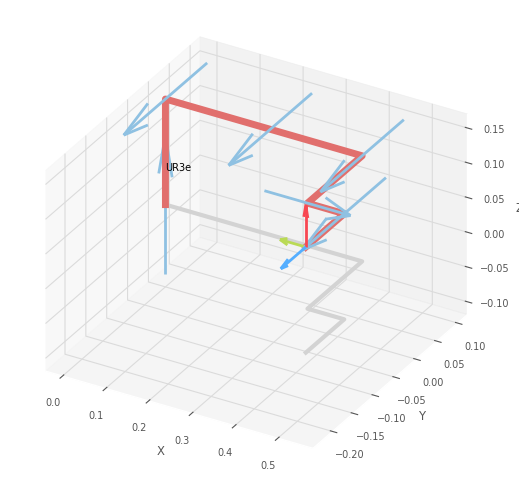

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'UR3e')

<Figure size 640x480 with 0 Axes>

In [358]:
stuck_joints = np.array([False, False, False, False, True, True])
stuck_angles = np.array([np.pi/4] * 6)

ur3e = BreakableRobot()

tcp_pos = np.array([0.1, 0.1, 0.3])
tcp_rot = np.array([np.pi, 0.0, 0.0])

q = ur3e.inv_kinematics(tcp_pos, tcp_rot, publish=False)

test_ur3e = build_ur3e()

T_check = test_ur3e.fkine(q)
print("\nCheck Pose:\n", T_check.t)
print("Q: ", q)

q = [0, -np.pi, 0, -np.pi/2, 0, 0]

# led 4 ligner forkert fortegn

print(test_ur3e.fkine_all(q).t)

test_ur3e.plot(q, backend='pyplot')